# Finetuning eines YOLO-Modells mit eigenen Datensätzen

In diesem Notebook wird beispielhaft gezeigt, wie das YOLO-Modell trainiert wurde. Dabei wird die Konfiguration des Trainings sowie auf die Auswertung genauer erläutert.

### Installation der benötigten Bibliothek

In [1]:
!pip install ultralytics==8.4.15
#!pip install ultralytics==8.4.10

## Anzahl der Trainings und Validation-Bilder

In [2]:
import os
print(os.getcwd()) 
#print(f"Train-All: {len([f for f in os.listdir('full_split_dataset/train')])}")
#print(f"Train-Images: {len([f for f in os.listdir('full_split_dataset/train')if f.endswith('.png')])}")
#print(f"Valid: {len([f for f in os.listdir('full_split_dataset/val') if f.endswith('.png')])}")

print(f"Train-All: {len([f for f in os.listdir('own_and_iam_dataset/train')])}")
print(f"Train-Images: {len([f for f in os.listdir('own_and_iam_dataset/train')if f.lower().endswith(('.jpeg', '.jpg', '.png'))])}")
print(f"Val-Images: {len([f for f in os.listdir('own_and_iam_dataset/val')if f.lower().endswith(('.jpeg', '.jpg', '.png'))])}")

print(f"Train-All: {len([f for f in os.listdir('own_dataset_split_125/train')])}")

/home/dedol002/final_yolo
Train-All: 400
Train-Images: 200
Val-Images: 50
Train-All: 200


## Laden des Modells
Quelle: [YOLO-Train](https://docs.ultralytics.com/modes/train/#usage-examples)

In [3]:

from ultralytics import YOLO

# Pretrained Modell
#model = YOLO("iam_trained_model/iam_model_seg_l/weights/best.pt")  # mit IAM als pre-trained-Modell
model = YOLO("yolo11l-seg.pt") 
#model = YOLO("yolo11s-seg.pt") 

## Training des Modells

Dazu wird das Modell testweise auf dem eigenen und auf einem gemischten Datensatz (IAM+OWN) trainiert. 

Die Datenaugmentierungen sowie weitere Trainingsparameter werden dabei dem automatischen Mechanismus von YOLO überlassen, da dieser in der Praxis bereits sehr gute Ergebnisse liefert:

In [4]:
model.train(
    data="own_and_iam_dataset.yaml",  
    #data="own_dataset.yaml",
    epochs=150,           
    imgsz=1280,            
    batch=4,             
    patience=30,
    project="new_own_trained_mixed",
    #project="new_own_trained_125_models",
    name="own_data_model_yolo11-l_def",
    #mosaic=0.0,
    #mixup=0.0,
    #cutmix=0.0,
    #hsv_h=0.0,
    #hsv_s=0.0,
    #hsv_v=0.0,
    #degrees=0.0,
    #translate=0.0,
    #scale=0.0,
    #shear=0.0,
    #perspective=0.0,
    #flipud=0.0,
    #fliplr=0.0,
    #auto_augment = None
)

New https://pypi.org/project/ultralytics/8.4.16 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.15 🚀 Python-3.11.6 torch-2.4.0+cu124 CUDA:0 (NVIDIA A100-SXM4-80GB MIG 3g.40gb, 40192MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=own_and_iam_dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11l-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f01ec71bdd0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.04104

## Beispiel zur Instanzerkennung

Im folgenden Abschnitt wird anhand eines Beispiels demonstriert, wie ein trainiertes YOLO-Modell zur Objekterkennung eingesetzt wird. Dabei wird ein Testbild verwendet, um zu zeigen, wie das Modell Objekte erkennt und klassifiziert.

### Laden eines fine-tuned Modells (das Modell das auch in der Pipeline genutzt wird)

In [5]:
from ultralytics import YOLO
trained_model = YOLO(r"E:\bachelor_projekte\htr_webapp\htr_webapp\backend\new_yolo_febr\weights\best.pt")

## Beispielbild laden

In [6]:
import cv2
img_path = r"E:\bachelor_projekte\overlap_masks\test_data_mixed\IMG_mixed_0.jpeg"
img = cv2.imread(img_path)

# Vorhersage
results = trained_model.predict(img, conf=0.5, iou=0.7, agnostic_nms=True)



0: 1280x960 11 Textlines, 4 Formulas, 952.3ms
Speed: 11.7ms preprocess, 952.3ms inference, 28.2ms postprocess per image at shape (1, 3, 1280, 960)


## Plotten der Detektionen:

In [7]:
%matplotlib inline

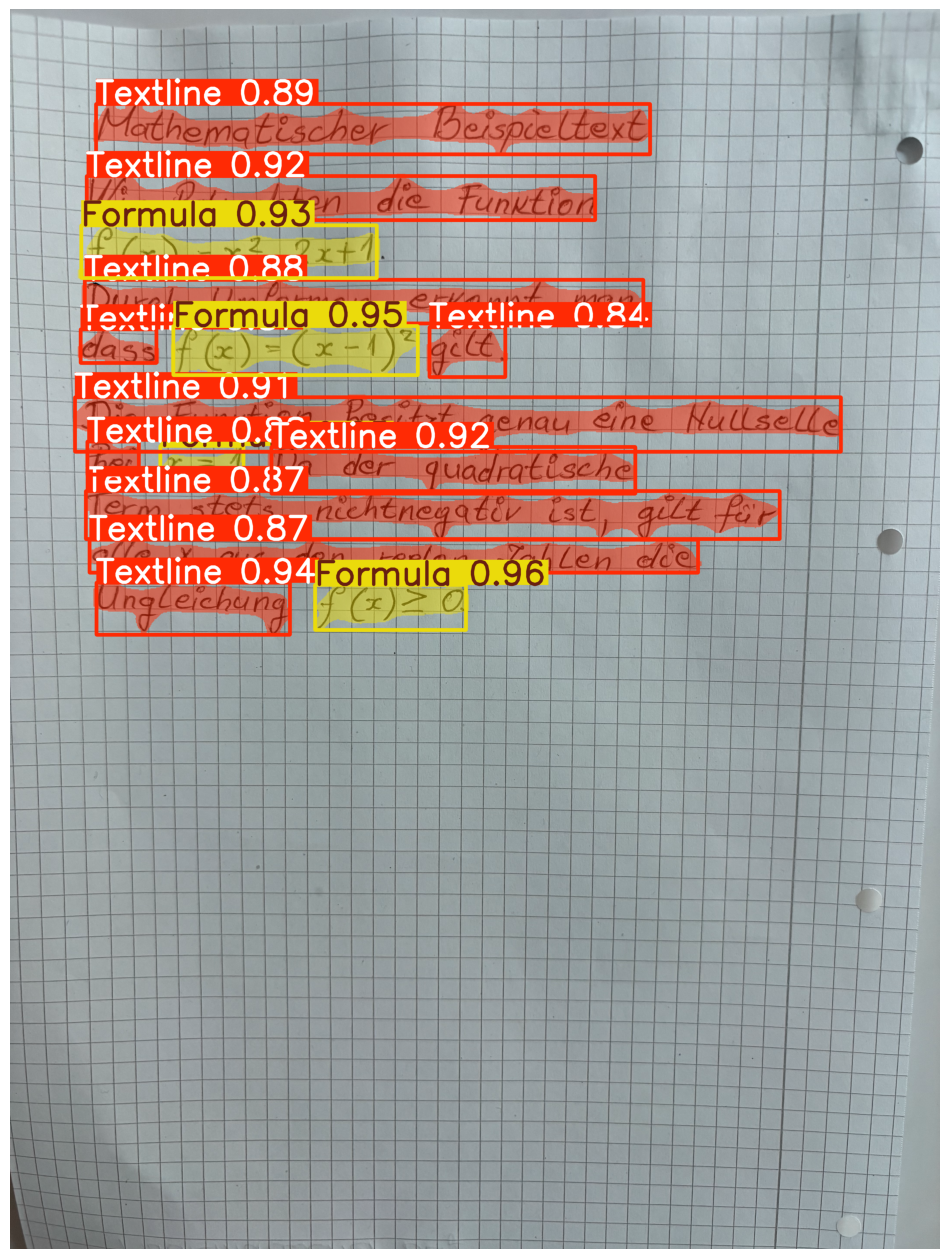

In [8]:
from matplotlib import pyplot as plt
plt.figure(figsize=(12, 18))  
plt.imshow(results[0].plot())
plt.axis("off")
plt.show()

## Ergebnis:
- Das Ergebnis zeigt, dass das Modell fast alle Instanzen erfolgreich erkannt hat.
- Zusätzlich kann es passieren, dass einige Masken fälschlicherweise im Hintergrund erkannt werden.
- Diese Probleme können durch [**Non-Maximum Suppression (NMS)**](https://www.ultralytics.com/de/glossary/non-maximum-suppression-nms) sowie weiteren **Postprocessing-Schritten** reduziert bzw. vollständig entfernt werden.
- Durch geeignete Filtermechanismen (z. B. IoU-Thresholds) lässt sich die Qualität der finalen Segmentierung deutlich verbessern.